<a href="https://colab.research.google.com/github/vituhaa/Healthy-Posture/blob/project/keras_openpose.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Проведение иференса модели OpenPose с соответствующими выводами, а также проведение процесса дообучения (fine-tuning) модели.

Проверка ресурсов nvidia для дальнейшего использования в работе с OpenPose

In [1]:
! nvcc --version
! nvidia-smi

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
Mon Feb 16 09:06:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   62C    P8       

Скачиваю необходимые зависимости для OpenPose

In [5]:
# ! sudo apt-get --assume-yes update
! sudo apt-get --assume-yes install build-essential
! sudo apt-get --assume-yes install libopencv-dev
! sudo apt-get --assume-yes install libatlas-base-dev libprotobuf-dev libleveldb-dev libsnappy-dev libhdf5-serial-dev protobuf-compiler
! sudo apt-get --assume-yes install --no-install-recommends libboost-all-dev
! sudo apt-get --assume-yes install libgflags-dev libgoogle-glog-dev liblmdb-dev
! sudo apt-get --assume-yes install python3-setuptools python3-dev build-essential
! sudo apt-get --assume-yes install python3-pip
! sudo -H pip3 install --upgrade numpy protobuf opencv-python
! sudo apt-get --assume-yes install opencl-headers ocl-icd-opencl-dev
! sudo apt-get --assume-yes install libviennacl-dev

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
build-essential is already the newest version (12.9ubuntu3).
0 upgraded, 0 newly installed, 0 to remove and 37 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  at-spi2-core gsettings-desktop-schemas gstreamer1.0-plugins-base
  libatk-bridge2.0-0 libatk1.0-0 libatk1.0-data libatspi2.0-0 libavcodec-dev
  libavformat-dev libavutil-dev libcdparanoia0 libcharls2 libdc1394-dev
  libdouble-conversion3 libexif-dev libexif-doc libexif12 libgdcm-dev
  libgdcm3.0 libgl2ps1.4 libglew2.2 libgphoto2-6 libgphoto2-dev
  libgphoto2-l10n libgphoto2-port12 libgstreamer-plugins-base1.0-0 libgtk-3-0
  libgtk-3-bin libgtk-3-common libilmbase-dev libilmbase25
  libopencv-calib3d-dev libopencv-calib3d4.5d libopencv-contrib-dev
  libopencv-contrib4.5d libopencv-core-dev libopencv-core4.5d
  libopencv

Перехожу в рабочую папку и клонирую репозиторий OpenPose

In [1]:
%%bash
cd /content
git clone https://github.com/CMU-Perceptual-Computing-Lab/openpose
cd openpose && git submodule update --init --recursive --remote

Submodule path '3rdparty/caffe': checked out '2d4bf549aabf97265f76b9599b82540dde9218ed'
Submodule path '3rdparty/pybind11': checked out '3ae5a173c54ab64339ad4a6c57557896b8bad6f9'


Cloning into 'openpose'...
Submodule '3rdparty/caffe' (https://github.com/CMU-Perceptual-Computing-Lab/caffe.git) registered for path '3rdparty/caffe'
Submodule '3rdparty/pybind11' (https://github.com/pybind/pybind11.git) registered for path '3rdparty/pybind11'
Cloning into '/content/openpose/3rdparty/caffe'...
Cloning into '/content/openpose/3rdparty/pybind11'...


In [4]:
! cmake --version

cmake version 3.31.10

CMake suite maintained and supported by Kitware (kitware.com/cmake).


Скачиваю веса модели COCO (https://huggingface.co/camenduru/openpose/tree/main/models/pose/coco), так как их нет в папке с моделью

In [2]:
%%bash
ls -lah /content/openpose/models/pose/coco/

total 56K
drwxr-xr-x 2 root root 4.0K Feb 16 09:35 .
drwxr-xr-x 5 root root 4.0K Feb 16 09:35 ..
-rwxr-xr-x 1 root root  46K Feb 16 09:35 pose_deploy_linevec.prototxt


In [3]:
%%bash
ls -lah /content/openpose/models/pose/coco/

total 3.1M
drwxr-xr-x 2 root root 4.0K Feb 16 09:36 .
drwxr-xr-x 5 root root 4.0K Feb 16 09:35 ..
-rwxr-xr-x 1 root root  46K Feb 16 09:35 pose_deploy_linevec.prototxt
-rw-r--r-- 1 root root 3.0M Feb 16 09:37 pose_iter_440000.caffemodel


Провожу операцию cmake внутри папки build, указывая флаги того, что нужно использовать

In [7]:
%%bash
cd /content/openpose
mkdir build
cd build
cmake .. \
  -DBUILD_PYTHON=OFF \
  -DBUILD_EXAMPLES=ON \
  -DGPU_MODE=CUDA \
  -DUSE_CUDNN=OFF
make -j"$(nproc)"

-- GCC detected, adding compile flags
-- GCC detected, adding compile flags
-- Building with CUDA.
-- CUDA detected: 12.8
-- Added CUDA NVCC flags for: sm_75
-- Found cuDNN: ver. 9.8.0 found (include: /usr/include, library: /usr/lib/x86_64-linux-gnu/libcudnn.so)
-- Found GFlags: /usr/include
-- Found gflags  (include: /usr/include, library: /usr/lib/x86_64-linux-gnu/libgflags.so)
-- Found Glog: /usr/include
-- Found glog    (include: /usr/include, library: /usr/lib/x86_64-linux-gnu/libglog.so)
-- Found Protobuf: /usr/lib/x86_64-linux-gnu/libprotobuf.so (found version "3.12.4")
-- Found OpenCV: /usr (found version "4.5.4")
-- Caffe will be downloaded from source now. NOTE: This process might take several minutes depending
        on your internet connection.
-- Caffe has already been downloaded.
-- Caffe will be built from source now.
-- Download the models.
-- Downloading BODY_25 model...
-- Model already exists.
-- Not downloading body (COCO) model
-- Not downloading body (MPI) model


mkdir: cannot create directory ‘build’: File exists
CMake Warning (dev) at CMakeLists.txt:19 (project):
  cmake_minimum_required() should be called prior to this top-level project()
  call.  Please see the cmake-commands(7) manual for usage documentation of
  both commands.
This warning is for project developers.  Use -Wno-dev to suppress it.

CMake Deprecation Warning at CMakeLists.txt:34 (cmake_minimum_required):
  Compatibility with CMake < 3.10 will be removed from a future version of
  CMake.

  Update the VERSION argument <min> value.  Or, use the <min>...<max> syntax
  to tell CMake that the project requires at least <min> but has been updated
  to work with policies introduced by <max> or earlier.


CMake Warning (dev) at CMakeLists.txt:214 (find_package):
  Policy CMP0146 is not set: The FindCUDA module is removed.  Run "cmake
  --help-policy CMP0146" for policy details.  Use the cmake_policy command to
  set the policy and suppress this warning.

This warning is for project d

Создаю директорию output, чтобы провести инференс модели на фото, которые находятся внутри папки examples/media. В output складываются фотографии с размеченными скелетами и .json файлы с аннотяциями.

In [8]:
%%bash
cd /content/openpose/
mkdir output

./build/examples/openpose/openpose.bin \
  --image_dir /content/openpose/examples/media \
  --write_images /content/openpose/output \
  --write_json /content/openpose/output \
  --display 0 \
  --render_pose 1 \
  --model_pose COCO

ls -lah /content/openpose/output

Starting OpenPose demo...
Configuring OpenPose...
Starting thread(s)...
Auto-detecting all available GPUs... Detected 1 GPU(s), using 1 of them starting at GPU 0.
OpenPose demo successfully finished. Total time: 6.679788 seconds.
total 8.2M
drwxr-xr-x  2 root root 4.0K Feb 16 10:06 .
drwxr-xr-x 15 root root 4.0K Feb 16 10:06 ..
-rw-r--r--  1 root root 2.4K Feb 16 10:06 COCO_val2014_000000000192_keypoints.json
-rw-r--r--  1 root root 605K Feb 16 10:06 COCO_val2014_000000000192_rendered.png
-rw-r--r--  1 root root 2.3K Feb 16 10:06 COCO_val2014_000000000241_keypoints.json
-rw-r--r--  1 root root 475K Feb 16 10:06 COCO_val2014_000000000241_rendered.png
-rw-r--r--  1 root root 3.5K Feb 16 10:06 COCO_val2014_000000000257_keypoints.json
-rw-r--r--  1 root root 539K Feb 16 10:06 COCO_val2014_000000000257_rendered.png
-rw-r--r--  1 root root  579 Feb 16 10:06 COCO_val2014_000000000294_keypoints.json
-rw-r--r--  1 root root 358K Feb 16 10:06 COCO_val2014_000000000294_rendered.png
-rw-r--r--  1 

Вывод фото в ноутбук

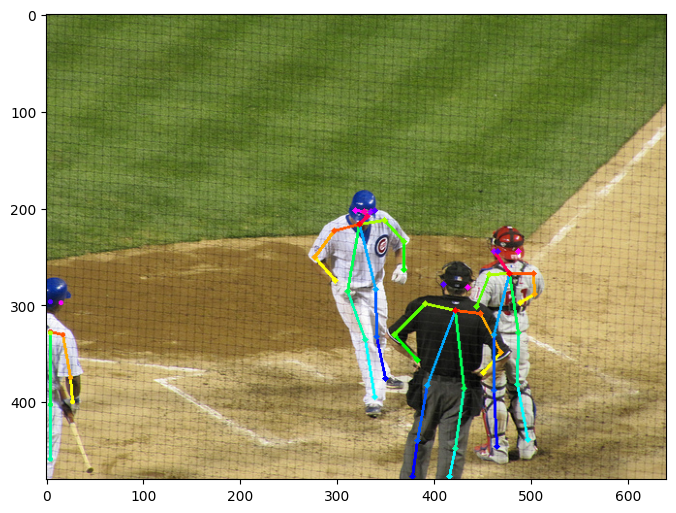

In [9]:
from matplotlib import pyplot as plt
from PIL import Image

res = Image.open('/content/openpose/output/COCO_val2014_000000000192_rendered.png')
plt.figure(figsize=(8, 8))
plt.imshow(res)
plt.show()

Инференс модели OpenPose прошёл успешно на базовых фотографиях, заложенных в репозитории. Проведём подобный эксперимент на фотографии сидячего человека и оценим результаты визуально.

In [15]:
%%bash
cd /content/openpose/
# mkdir output

./build/examples/openpose/openpose.bin \
  --image_dir /content/openpose/examples/media/sitting_poses \
  --write_images /content/openpose/output \
  --write_json /content/openpose/output \
  --display 0 \
  --render_pose 1 \
  --model_pose COCO

# ls -lah /content/openpose/output

Starting OpenPose demo...
Configuring OpenPose...
Starting thread(s)...
Auto-detecting all available GPUs... Detected 1 GPU(s), using 1 of them starting at GPU 0.
OpenPose demo successfully finished. Total time: 4.722643 seconds.


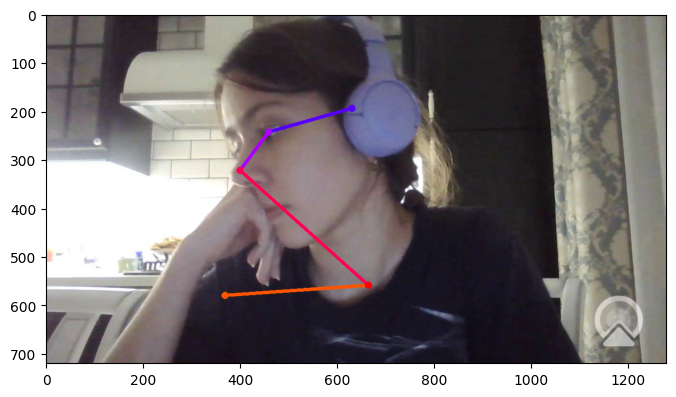

In [16]:
res = Image.open('/content/openpose/output/frame_0001_rendered.png')
plt.figure(figsize=(8, 8))
plt.imshow(res)
plt.show()

Визуально модель хорошо справляется с определением ключевых точек на теле сидячего человека, но, как можно заметить, с определением левого плеча и правой руки модель не справилась. Сделаем вывод на основе метрик качества.

## Покажем качество модели на фото сидячих людей.

Посмотрим исходное качество модели на фото из датасета COCO.

In [ ]:
%%bash
mkdir coco/photos
cd coco/photos
wget http://images.cocodataset.org/zips/train2017.zip
wget http://images.cocodataset.org/zips/val2017.zip
unzip train2017.zip
unzip val2017.zip

In [ ]:
%%bash
mkdir coco/keypoints
cd coco/keypoints
wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip
unzip annotations_trainval2017.zip

In [ ]:
%%bash
cd /content/openpose
./scripts/test/pose_accuracy_coco_val.sh

Также посмотрим качество на нашем кастомном датасете с сидячими людьми.

In [ ]:
%%bash
cd /content/openpose/
mkdir experiment_output

./build/examples/openpose/openpose.bin \
  --image_dir /content/openpose/examples/media/sitting_poses \
  --write_images /content/openpose/experiment_output \ # вывод разметки
  --write_json /content/openpose/experiment_output \
  --display 0 \
  --render_pose 1 \
  --model_pose COCO

ls -lah /content/openpose/experiment_output # проверим что вывод лежит там

In [ ]:
# загрузка эталонной разметки

Теперь запустим скрипт для сравнения эталонной разметки с той, которая получилась у модели (фото должны быть заранее размечены).

In [ ]:
%%bash
cd /content/openpose
./scripts/test/pose_accuracy_coco_val.sh  # поменять пути

Вывод:

## Попытаемся дообучить модель OpenPose на датасете сидячих людей, чтобы модель лучше предсказывала нахождение ключевых точек на теле людей и сделаем вывод.

Вывод:

## Создание нейронной сети:

In [ ]:
# показываю датасет:
class_names = ['good', 'bad']

In [ ]:
import keras
from keras import layers # 19 layers

input = keras.Input(shape=(64, 64, 3)) # посмотреть как писать размерность
x = keras.layers.Dense( , activation="relu")(input)
pooling = keras.layer.Pooling2D()()

output = keras.layers.Dense( , activation="softmax")(x) # вывод
keras_model = keras.Model(inputs=input, outputs=output)